# Notebook 4 — Stage-2 Damping Interpretation
### Detectability-Aware Post-Merger GW Anomaly Screening — Project Notebook 4

This notebook applies the Stage-1 gate from Notebooks 3/3.5 and evaluates damping-time estimates for the
candidates that pass it.

The analysis uses two Stage-2 estimators:

- a CQT ridge/energy-decay estimate of `tau`;
- a nonlinear damped-sinusoid least-squares estimate as an independent baseline.

Synthetic injections with `tau = 1, 3 ms` are treated as anomalous and `tau = 5, 10, 20, 40 ms` as
standard. A total-CQT-power classifier is included as a non-`tau` baseline.

`calib_block` is used for Stage-1 and ridge noise-floor calibration. Development sweeps and Stage-2
thresholds use `train_block`. `test_block` is not loaded in this notebook.

Both conditional performance (Stage-1 passers only) and end-to-end performance (all injections) are
reported. The results here are development results because the Stage-2 thresholds are calibrated on the
same `train_block` sweep used for evaluation.

**Depends on:** `nb1_artifacts/` from Notebook 1. Core preprocessing and injection functions are defined
locally with the same settings used in the preceding notebooks.


In [1]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa


## 1. Setup

Load `calib_block` and `train_block` together with the operational PSD from Notebook 1. `test_block` is
intentionally left out of the noise-pool dictionary used by this notebook.


In [2]:
# ---------------------------------------------------------------------------
# 1. Imports, config, and Notebook 1 artifacts
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import librosa
from google.colab import drive; drive.mount('/content/drive')


SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb4_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found; run Notebook 1 first."

FS = 16384
WINDOW_DUR = 0.1
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)
F_LOW = 20.0
F_HIGH = 6000.0
EDGE_TRIM_S = 4.0
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))

BLOCKS = json.load(open(os.path.join(NB1_DIR, "gps_blocks.json")))
_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)
_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    assert np.all(np.isfinite(data))
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out))
    return out

def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0
    return h_t * (target_snr / base)

# Development noise pools; test_block is not loaded here.
raw_noise_pools = {}
for name in ['calib_block', 'train_block']:
    arr = np.load(os.path.join(NB1_DIR, f"raw_{name}_L1.npy"))
    assert np.all(np.isfinite(arr))
    raw_noise_pools[name] = arr
    print(f"{name:12s}: loaded {len(arr)} samples ({len(arr)/FS:.0f}s)")
print("test_block: not loaded")

def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    assert block_name != 'test_block', "test_block is not available in Notebook 4."
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)
    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled
    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    assert block_name != 'test_block', "test_block is not available in Notebook 4."
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx


Mounted at /content/drive
calib_block : loaded 16777216 samples (1024s)
train_block : loaded 16777216 samples (1024s)
test_block: not loaded


## 2. Stage-1 gate

Rebuild the CQT normalization and `norm_lambda1` statistic used in Notebooks 3/3.5. The Stage-1 null
threshold is recalibrated with 4000 `calib_block` noise windows at `alpha=0.01`.


In [3]:
# ---------------------------------------------------------------------------
# 2. Stage-1 machinery and null threshold
# ---------------------------------------------------------------------------
CQT_FMIN = 500.0
CQT_N_BINS = 48
CQT_BINS_PER_OCTAVE = 12
CQT_HOP_LENGTH = 8
CQT_BAND_LOW = 1500.0
CQT_BAND_HIGH = 4000.0

_cqt_all_freqs = librosa.cqt_frequencies(n_bins=CQT_N_BINS, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE)
_cqt_band_mask = (_cqt_all_freqs >= CQT_BAND_LOW) & (_cqt_all_freqs <= CQT_BAND_HIGH)
cqt_band_freqs = _cqt_all_freqs[_cqt_band_mask]

def compute_cqt_banded(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH,
                        band_mask=_cqt_band_mask):
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)[band_mask, :]

N_NORM_SAMPLES = 500
_norm_stack = []
for _ in range(N_NORM_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    _norm_stack.append(np.log1p(compute_cqt_banded(w)))
_norm_stack = np.stack(_norm_stack, axis=0)
cqt_bin_median = np.median(_norm_stack, axis=0)
cqt_bin_mad = np.median(np.abs(_norm_stack - cqt_bin_median[None, :, :]), axis=0)
cqt_bin_mad_safe = np.maximum(1.4826 * cqt_bin_mad, 1e-6)
del _norm_stack

def normalize_cqt(mag):
    return np.maximum((np.log1p(mag) - cqt_bin_median) / cqt_bin_mad_safe, 0.0)

GRAPH_FREQ_RADIUS = 2
GRAPH_TIME_RADIUS = 2

def build_tf_graph(tf_map, freq_radius=GRAPH_FREQ_RADIUS, time_radius=GRAPH_TIME_RADIUS):
    n_freq, n_time = tf_map.shape
    n = n_freq * n_time
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols, data = [], [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            w = (tf_map[f_src, t_src] * tf_map[f_dst, t_dst]).reshape(-1)
            rows.append(src_idx); cols.append(dst_idx); data.append(w)
    rows = np.concatenate(rows); cols = np.concatenate(cols); data = np.concatenate(data)
    return scipy.sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

def leading_eigenvalue(A):
    if A.nnz == 0:
        return 0.0
    try:
        return float(scipy.sparse.linalg.eigsh(A, k=1, which='LA', return_eigenvectors=False)[0])
    except Exception:
        return float(np.linalg.eigvalsh(A.toarray())[-1])

def stage1_statistic(window):
    """Return the normalized graph leading-eigenvalue statistic."""
    z_pos = normalize_cqt(compute_cqt_banded(window))
    return leading_eigenvalue(build_tf_graph(z_pos))

def total_power_raw(window):
    return float(compute_cqt_banded(window).sum())

# Stage-1 null threshold from calib_block noise.
N_CALIBRATION = 4000
ALPHA = 0.01
null_norm_lambda1 = np.empty(N_CALIBRATION)
for i in range(N_CALIBRATION):
    w, _ = make_noise_only_window('calib_block')
    null_norm_lambda1[i] = stage1_statistic(w)
    if (i + 1) % 1000 == 0:
        print(f"  calibrated {i+1}/{N_CALIBRATION}...")

STAGE1_THRESHOLD = np.percentile(null_norm_lambda1, 100 * (1 - ALPHA))
n_expected = ALPHA * N_CALIBRATION
print(f"\nalpha={ALPHA}: threshold={STAGE1_THRESHOLD:.4f}  "
      f"(~{n_expected:.0f} expected exceedances)")

def stage1_pass(window):
    return stage1_statistic(window) > STAGE1_THRESHOLD


  calibrated 1000/4000...
  calibrated 2000/4000...
  calibrated 3000/4000...
  calibrated 4000/4000...

alpha=0.01: threshold=55.6439  (~40 expected exceedances)


## 3. Stage-2 damping-time estimators

### Ridge / energy-decay estimate

For each CQT time frame, sum the squared in-band magnitude over frequency. If the signal envelope behaves
as $h(t)\propto e^{-t/\tau}$, its power behaves approximately as $e^{-2t/\tau}$, so the slope of
`log(frame_power)` gives an effective damping time.

The fit begins at the peak-power frame and stops after the frame power reaches a `calib_block` noise-floor
reference for two consecutive frames. The adaptive stop keeps long noise-only tails from dominating the
fit for short-lived injections.

### Nonlinear least-squares estimate

As an independent baseline, fit a damped sinusoid directly to the whitened time-domain window with
`scipy.optimize.curve_fit`.


In [4]:
# ---------------------------------------------------------------------------
# 3. Stage-2 tau-hat estimators
# ---------------------------------------------------------------------------
# Calibrate the frame-power level used to stop the ridge fit once the decay reaches the noise floor.
N_NOISE_FLOOR_SAMPLES = 300
_noise_frame_powers = []
for _ in range(N_NOISE_FLOOR_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    mag = compute_cqt_banded(w)
    _noise_frame_powers.append(np.sum(mag**2, axis=0))
_noise_frame_powers = np.concatenate(_noise_frame_powers)
RIDGE_STOP_PERCENTILE = 90.0
RIDGE_NOISE_FLOOR = np.percentile(_noise_frame_powers, RIDGE_STOP_PERCENTILE)
print(f"Ridge noise-floor threshold ({RIDGE_STOP_PERCENTILE:.0f}th percentile of calib_block "
      f"frame power): {RIDGE_NOISE_FLOOR:.2f}")
del _noise_frame_powers

def estimate_tau_ridge(window, fit_max_frames=60, min_frames_for_fit=4, patience=2,
                        noise_floor=RIDGE_NOISE_FLOOR, fs=FS, hop_length=CQT_HOP_LENGTH):
    """Estimate tau from the post-peak log frame-power slope with a noise-floor stopping rule."""
    mag = compute_cqt_banded(window)
    frame_power = np.sum(mag**2, axis=0)
    times = np.arange(mag.shape[1]) * hop_length / fs
    peak_idx = int(np.argmax(frame_power))
    max_end = min(peak_idx + fit_max_frames, len(frame_power))

    end_idx = max_end
    below_count = 0
    for idx in range(peak_idx + 1, max_end):
        if frame_power[idx] <= noise_floor:
            below_count += 1
            if below_count >= patience:
                end_idx = idx - patience + 1  # stop where the run below the floor began
                break
        else:
            below_count = 0

    fit_idx = np.arange(peak_idx, end_idx)
    if len(fit_idx) < min_frames_for_fit:
        return None

    fit_times = times[fit_idx] - times[peak_idx]
    fit_power = np.maximum(frame_power[fit_idx], 1e-12)
    log_power = np.log(fit_power)

    A = np.vstack([fit_times, np.ones_like(fit_times)]).T
    slope, _intercept = np.linalg.lstsq(A, log_power, rcond=None)[0]
    if slope >= 0:
        return None  # non-decaying fitted slope
    return -2.0 / slope

def _damped_sinusoid_model(t, A, tau, f, phi):
    return A * np.exp(-t / tau) * np.sin(2 * np.pi * f * t + phi)

def estimate_tau_lsq(window, fs=FS, band_low=CQT_BAND_LOW, band_high=CQT_BAND_HIGH):
    """Estimate tau with a nonlinear damped-sinusoid least-squares fit."""
    n = len(window)
    t = np.arange(n) / fs
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    band = (freqs >= band_low) & (freqs <= band_high)
    fft_mag = np.abs(np.fft.rfft(window))
    f0_guess = freqs[band][np.argmax(fft_mag[band])] if band.any() else 0.5 * (band_low + band_high)
    A0_guess = np.max(np.abs(window))
    p0 = [A0_guess, 0.01, f0_guess, 0.0]
    bounds = ([0, 1e-4, band_low, -np.pi], [np.inf, 0.5, band_high, np.pi])
    try:
        popt, _ = curve_fit(_damped_sinusoid_model, t, window, p0=p0, bounds=bounds, maxfev=5000)
        return float(popt[1])
    except Exception:
        return None


Ridge noise-floor threshold (90th percentile of calib_block frame power): 274565.08


## 4. Estimator check

Run both damping estimators on a small set of known-`tau` injections at SNR 10 and 20 before the main
sweep.


In [5]:
# ---------------------------------------------------------------------------
# 4. Sanity check
# ---------------------------------------------------------------------------
print(f"{'true_tau_ms':>12s}  {'SNR':>5s}  {'tau_hat_ridge_ms':>17s}  {'tau_hat_lsq_ms':>15s}")
for true_tau_ms in [1, 3, 5, 10, 20, 40]:
    for snr in [10, 20]:
        f_peak = rng.uniform(1500.0, 4000.0)
        w, _, _ = inject_and_whiten('train_block', f_peak=f_peak, tau=true_tau_ms / 1000.0,
                                     target_snr=float(snr))
        ridge = estimate_tau_ridge(w)
        lsq = estimate_tau_lsq(w)
        ridge_str = f"{ridge*1000:17.2f}" if ridge is not None else f"{'None':>17s}"
        lsq_str = f"{lsq*1000:15.2f}" if lsq is not None else f"{'None':>15s}"
        print(f"{true_tau_ms:12d}  {snr:5d}  {ridge_str}  {lsq_str}")


 true_tau_ms    SNR   tau_hat_ridge_ms   tau_hat_lsq_ms
           1     10               3.05             0.54
           1     20               5.83             0.79
           3     10               4.08             2.28
           3     20               4.01             2.47
           5     10              13.26             4.16
           5     20              10.71             6.56
          10     10              55.69             8.63
          10     20              14.58             9.76
          20     10              10.73            23.58
          20     20              46.27            21.09
          40     10              18.60            30.97
          40     20              32.87            40.09


## 5. Main Stage-2 sweep

Generate injections on `train_block` for `tau = [1, 3, 5, 10, 20, 40]` ms and
`SNR = [8, 10, 12, 15, 20]`.

Each window first passes through the Stage-1 gate. Damping estimates and total CQT power are computed only
for Stage-1 passers. Stage-1 pass/fail is saved for every injection so the same records can be used for
conditional and end-to-end metrics.


In [6]:
# ---------------------------------------------------------------------------
# 5. Main sweep
# ---------------------------------------------------------------------------
TAU_GRID_MS = [1, 3, 5, 10, 20, 40]
STANDARD_TAUS_MS = {5, 10, 20, 40}
ANOMALOUS_TAUS_MS = {1, 3}
SNR_GRID = [8, 10, 12, 15, 20]
N_PER_CELL = 60

records = []
for tau_ms in TAU_GRID_MS:
    for snr in SNR_GRID:
        for _ in range(N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('train_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=float(snr))
            passed = stage1_pass(w)
            rec = {'tau_ms': tau_ms, 'snr': snr, 'f_peak': f_peak,
                   'is_anomalous': tau_ms in ANOMALOUS_TAUS_MS, 'stage1_pass': bool(passed)}
            if passed:
                rec['tau_hat_ridge'] = estimate_tau_ridge(w)
                rec['tau_hat_lsq'] = estimate_tau_lsq(w)
                rec['total_power_raw'] = total_power_raw(w)
            records.append(rec)
    print(f"  tau={tau_ms:3d}ms done")

n_total = len(records)
n_passed = sum(r['stage1_pass'] for r in records)
print(f"\n{n_total} total injections, {n_passed} ({100*n_passed/n_total:.1f}%) passed Stage-1")

with open(os.path.join(OUT_DIR, 'stage2_records.json'), 'w') as f:
    json.dump(records, f, indent=1)
print(f"Saved {os.path.join(OUT_DIR, 'stage2_records.json')}")


  tau=  1ms done
  tau=  3ms done
  tau=  5ms done
  tau= 10ms done
  tau= 20ms done
  tau= 40ms done

1800 total injections, 1617 (89.8%) passed Stage-1
Saved /content/drive/MyDrive/gw_postmerger/nb4_artifacts/stage2_records.json


## 6. Damping-time recovery

For the standard-damping samples that pass Stage 1, compare each estimated `tau` with the injected value.
The scatter plots are colored by SNR.


Ridge/energy-decay tau_hat: 1022/1030 standard-tau Stage-1-passers had a valid fit (99%)
Nonlinear LSQ tau_hat: 1030/1030 standard-tau Stage-1-passers had a valid fit (100%)


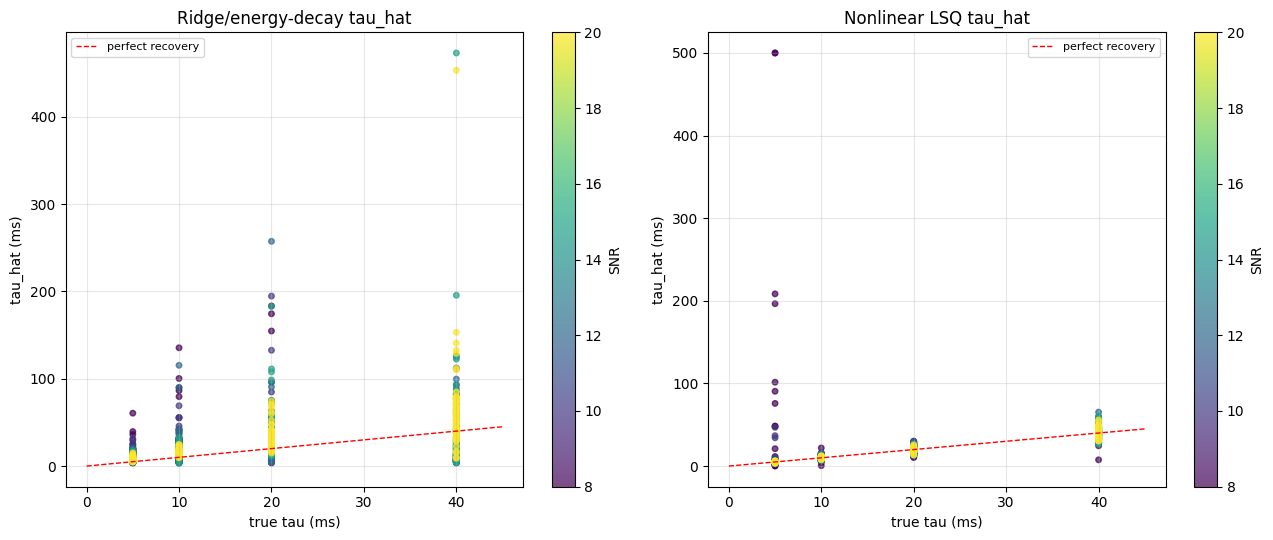

In [7]:
# ---------------------------------------------------------------------------
# 6. tau-hat recovery diagnostic
# ---------------------------------------------------------------------------
std_records = [r for r in records if r['stage1_pass'] and r['tau_ms'] in STANDARD_TAUS_MS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, key, title in [(axes[0], 'tau_hat_ridge', 'Ridge/energy-decay tau_hat'),
                        (axes[1], 'tau_hat_lsq', 'Nonlinear LSQ tau_hat')]:
    xs = [r['tau_ms'] for r in std_records if r[key] is not None]
    ys = [r[key] * 1000 for r in std_records if r[key] is not None]
    cs = [r['snr'] for r in std_records if r[key] is not None]
    sc = ax.scatter(xs, ys, c=cs, cmap='viridis', s=16, alpha=0.7)
    ax.plot([0, 45], [0, 45], 'r--', lw=1, label='perfect recovery')
    ax.set_xlabel('true tau (ms)'); ax.set_ylabel('tau_hat (ms)')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='SNR')
    n_valid = len(xs); n_total_std = sum(1 for r in std_records)
    print(f"{title}: {n_valid}/{n_total_std} standard-tau Stage-1-passers had a valid fit "
          f"({100*n_valid/max(n_total_std,1):.0f}%)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_tau_recovery.pdf'))
plt.show()


## 7. Stage-2 decision thresholds

For each damping estimator, use the 1st percentile of the standard-sample `tau_hat` distribution as the
anomaly threshold: a candidate is flagged when `tau_hat` falls below that value.

The power baseline is a logistic regression using `total_power_raw` as its only feature.

All thresholds and the power classifier are fit on the same `train_block` sweep evaluated below. These
are therefore in-sample development metrics, not the final held-out evaluation.


In [8]:
# ---------------------------------------------------------------------------
# 7. Stage-2 threshold and power-baseline calibration
# ---------------------------------------------------------------------------
ANOMALY_PERCENTILE = 1.0  # lower tail of the standard-damping distribution

def standard_tau_hat_values(key):
    return np.array([r[key] for r in records if r['stage1_pass'] and r['tau_ms'] in STANDARD_TAUS_MS
                      and r.get(key) is not None])

tau_thresholds = {}
for key in ['tau_hat_ridge', 'tau_hat_lsq']:
    vals = standard_tau_hat_values(key)
    tau_thresholds[key] = np.percentile(vals, ANOMALY_PERCENTILE)
    print(f"{key:16s}: standard-sample n={len(vals)}, "
          f"{ANOMALY_PERCENTILE:.0f}th-percentile threshold={tau_thresholds[key]*1000:.3f}ms")

# Power baseline: logistic regression using total_power_raw only.
passing = [r for r in records if r['stage1_pass'] and r.get('total_power_raw') is not None]
X_power = np.array([[r['total_power_raw']] for r in passing])
y_anom = np.array([r['is_anomalous'] for r in passing]).astype(int)
power_clf = LogisticRegression().fit(X_power, y_anom)
print(f"\nPower-baseline logistic regression fit on {len(passing)} Stage-1-passing samples "
      f"({y_anom.sum()} anomalous, {len(y_anom)-y_anom.sum()} standard)")

def flag_ridge(r):
    return r.get('tau_hat_ridge') is not None and r['tau_hat_ridge'] < tau_thresholds['tau_hat_ridge']

def flag_lsq(r):
    return r.get('tau_hat_lsq') is not None and r['tau_hat_lsq'] < tau_thresholds['tau_hat_lsq']

def flag_power(r):
    if r.get('total_power_raw') is None:
        return False
    return bool(power_clf.predict([[r['total_power_raw']]])[0])


tau_hat_ridge   : standard-sample n=1022, 1th-percentile threshold=4.165ms
tau_hat_lsq     : standard-sample n=1030, 1th-percentile threshold=3.216ms

Power-baseline logistic regression fit on 1617 Stage-1-passing samples (587 anomalous, 1030 standard)


## 8. Conditional and end-to-end performance

**Conditional** rates use only Stage-1-passing injections in the denominator.

**End-to-end** rates use all injections. A Stage-1 rejection is therefore counted as not flagged, which
makes a rejected anomalous injection a miss.


In [9]:
# ---------------------------------------------------------------------------
# 8. Conditional vs. end-to-end performance
# ---------------------------------------------------------------------------
METHODS = {'ridge': flag_ridge, 'lsq': flag_lsq, 'power': flag_power}

def compute_rates(records_subset, flag_fn, denom_mode):
    """Compute anomaly TPR and standard-sample FPR under the selected denominator."""
    anom = [r for r in records_subset if r['is_anomalous']]
    std = [r for r in records_subset if not r['is_anomalous']]
    if denom_mode == 'conditional':
        anom = [r for r in anom if r['stage1_pass']]
        std = [r for r in std if r['stage1_pass']]
    n_anom, n_std = len(anom), len(std)
    tpr = sum(1 for r in anom if r['stage1_pass'] and flag_fn(r)) / n_anom if n_anom else float('nan')
    fpr = sum(1 for r in std if r['stage1_pass'] and flag_fn(r)) / n_std if n_std else float('nan')
    return tpr, fpr, n_anom, n_std

print(f"{'method':8s} {'mode':12s} {'TPR (anomaly recall)':>21s} {'FPR (false flag rate)':>22s}")
summary_rows = []
for name, flag_fn in METHODS.items():
    for mode in ['conditional', 'end_to_end']:
        tpr, fpr, n_anom, n_std = compute_rates(records, flag_fn, mode)
        print(f"{name:8s} {mode:12s} {tpr:21.3f} {fpr:22.3f}   (n_anom={n_anom}, n_std={n_std})")
        summary_rows.append({'method': name, 'mode': mode, 'tpr': tpr, 'fpr': fpr,
                              'n_anom': n_anom, 'n_std': n_std})

with open(os.path.join(OUT_DIR, 'conditional_vs_endtoend.json'), 'w') as f:
    json.dump(summary_rows, f, indent=1)
print(f"\nSaved {os.path.join(OUT_DIR, 'conditional_vs_endtoend.json')}")

# Conditional flag rate by injected damping time for the ridge estimator.
print("\nConditional TPR/FPR by tau, ridge method:")
for tau_ms in TAU_GRID_MS:
    subset = [r for r in records if r['tau_ms'] == tau_ms]
    tpr, fpr, n_a, n_s = compute_rates(subset, flag_ridge, 'conditional')
    label = 'anomalous' if tau_ms in ANOMALOUS_TAUS_MS else 'standard'
    rate = tpr if tau_ms in ANOMALOUS_TAUS_MS else fpr
    print(f"  tau={tau_ms:3d}ms ({label:9s}): conditional flag rate = {rate:.3f}")


method   mode          TPR (anomaly recall)  FPR (false flag rate)
ridge    conditional                  0.455                  0.011   (n_anom=587, n_std=1030)
ridge    end_to_end                   0.445                  0.009   (n_anom=600, n_std=1200)
lsq      conditional                  0.819                  0.011   (n_anom=587, n_std=1030)
lsq      end_to_end                   0.802                  0.009   (n_anom=600, n_std=1200)
power    conditional                  0.000                  0.000   (n_anom=587, n_std=1030)
power    end_to_end                   0.000                  0.000   (n_anom=600, n_std=1200)

Saved /content/drive/MyDrive/gw_postmerger/nb4_artifacts/conditional_vs_endtoend.json

Conditional TPR/FPR by tau, ridge method:
  tau=  1ms (anomalous): conditional flag rate = 0.704
  tau=  3ms (anomalous): conditional flag rate = 0.205
  tau=  5ms (standard ): conditional flag rate = 0.017
  tau= 10ms (standard ): conditional flag rate = 0.011
  tau= 20ms (standa

## 9. ROC/AUC comparison

Compare the ridge estimate, nonlinear LSQ estimate, and total-power score on all Stage-1-passing samples
pooled across the `(tau, SNR)` grid.


ridge (tau_hat, inverted)   : AUC=0.922  (n=1600)
lsq (tau_hat, inverted)     : AUC=0.935  (n=1617)
power                       : AUC=0.287  (n=1617)


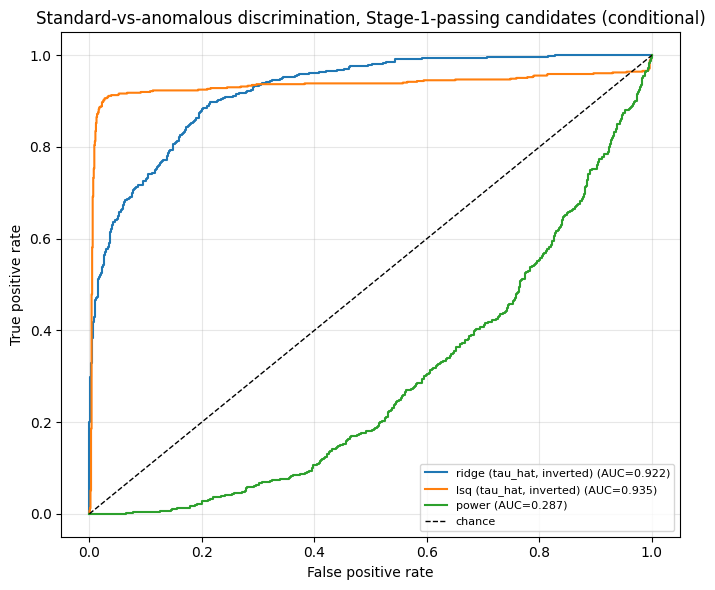

In [10]:
# ---------------------------------------------------------------------------
# 9. ROC / AUC comparison
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
for name, score_key, higher_is_anomalous in [
        ('ridge (tau_hat, inverted)', 'tau_hat_ridge', False),
        ('lsq (tau_hat, inverted)', 'tau_hat_lsq', False),
        ('power', 'total_power_raw', True)]:
    subset = [r for r in records if r['stage1_pass'] and r.get(score_key) is not None]
    y_true = np.array([r['is_anomalous'] for r in subset]).astype(int)
    scores = np.array([r[score_key] for r in subset])
    if not higher_is_anomalous:
        scores = -scores  # higher score corresponds to a shorter fitted damping time
    if len(np.unique(y_true)) < 2:
        print(f"{name}: skipped; subset contains one class")
        continue
    auc = roc_auc_score(y_true, scores)
    fpr_curve, tpr_curve, _ = roc_curve(y_true, scores)
    ax.plot(fpr_curve, tpr_curve, label=f'{name} (AUC={auc:.3f})')
    print(f"{name:28s}: AUC={auc:.3f}  (n={len(subset)})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('Standard-vs-anomalous discrimination, Stage-1-passing candidates (conditional)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_roc_comparison.pdf'))
plt.show()


## 9b. Optional learned baseline

No CNN or AST/Mahalanobis classifier is implemented in this notebook. A learned comparison, if added,
would be trained on development data and evaluated with the same conditional/end-to-end reporting used
above.


## 10. Artifacts and remaining checks

```text
nb4_artifacts/
  stage2_records.json
  plot_tau_recovery.pdf
  conditional_vs_endtoend.json
  plot_roc_comparison.pdf
```

`stage2_records.json` stores the injection parameters, Stage-1 result, available damping estimates, and
total-power value for each sample.

The main limitation is that the Stage-2 thresholds and power classifier are calibrated and evaluated on
the same `train_block` sweep. The final evaluation therefore still requires the held-out `test_block`.

